In [ ]:
!pip install pandas numpy scikit-learn

In [ ]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
movies = pd.read_csv('movies.csv')
ratings = pd.read_csv('ratings.csv')

print(movies.head())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


In [ ]:
print(movies.shape)
print(ratings.shape)

(9742, 3)
(100836, 4)


In [ ]:
movies['genres'] = movies['genres'].fillna('')

In [ ]:
# Convert Text into Vectors

In [ ]:
cv = CountVectorizer(max_features=5000, stop_words='english')

vector = cv.fit_transform(movies['genres']).toarray()

print(vector.shape)

(9742, 23)


In [ ]:
similarity = cosine_similarity(vector)

print(similarity)

[[1.         0.77459667 0.31622777 ... 0.         0.31622777 0.4472136 ]
 [0.77459667 1.         0.         ... 0.         0.         0.        ]
 [0.31622777 0.         1.         ... 0.         0.         0.70710678]
 ...
 [0.         0.         0.         ... 1.         0.         0.        ]
 [0.31622777 0.         0.         ... 0.         1.         0.        ]
 [0.4472136  0.         0.70710678 ... 0.         0.         1.        ]]


In [ ]:
def recommend(movie_name):

    if movie_name not in movies['title'].values:
        print("Movie not found")
        return

    movie_index = movies[movies['title'] == movie_name].index[0]

    distances = similarity[movie_index]

    movies_list = sorted(
        list(enumerate(distances)),
        reverse=True,
        key=lambda x: x[1]
    )[1:6]

    print(f"Recommended movies for {movie_name}:\n")

    for i in movies_list:
        print(movies.iloc[i[0]].title)

In [ ]:
recommend('Toy Story (1995)')

Recommended movies for Toy Story (1995):

Antz (1998)
Toy Story 2 (1999)
Adventures of Rocky and Bullwinkle, The (2000)
Emperor's New Groove, The (2000)
Monsters, Inc. (2001)


In [ ]:
# Add User Input
movie_name = input("Enter movie name: ")

recommend(movie_name)

Enter movie name: Antz (1998)
Recommended movies for Antz (1998):

Antz (1998)
Toy Story 2 (1999)
Adventures of Rocky and Bullwinkle, The (2000)
Emperor's New Groove, The (2000)
Monsters, Inc. (2001)


In [ ]:
top_movies = ratings.groupby('movieId')['rating'].count()

top_movies = top_movies.sort_values(
    ascending=False
).head(10)

print(top_movies)

movieId
356     329
318     317
296     307
593     279
2571    278
260     251
480     238
110     237
589     224
527     220
Name: rating, dtype: int64


In [ ]:
avg_rating = ratings.groupby('movieId')['rating'].mean()

print(avg_rating.sort_values(
    ascending=False
).head(10))

movieId
187717    5.0
6983      5.0
5328      5.0
95843     5.0
3941      5.0
3940      5.0
3939      5.0
7815      5.0
162414    5.0
162344    5.0
Name: rating, dtype: float64


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

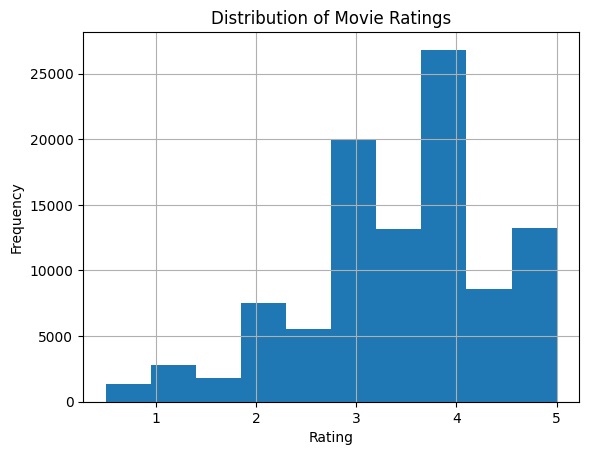

In [ ]:
ratings['rating'].hist(bins=10)

plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.title("Distribution of Movie Ratings")

plt.show()